In [2]:
# Cell 1: Import libraries + Load data

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Download data from Kaggle and place in the same directory
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

print("Training set:", train.shape)
print("Test set:", test.shape)

Training set: (1460, 81)
Test set: (1459, 80)


In [3]:
print(test.columns.tolist())

['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'PoolQC'

In [4]:
# Cell 2: Data Processing
# Save test Id for submission

test_ids = test['Id']

# Merge train and test for unified feature engineering
all_data = pd.concat([train.drop('SalePrice', axis=1), test], axis=0).reset_index(drop=True)

# Fill missing values: median for numeric, 'None' for categorical
for col in all_data.columns:
    if all_data[col].dtype == 'object' or all_data[col].dtype.name == 'string':
        all_data[col].fillna('None', inplace=True)
    elif pd.api.types.is_numeric_dtype(all_data[col]):
        all_data[col].fillna(all_data[col].median(), inplace=True)
    else:
        all_data[col].fillna('None', inplace=True)

print("Missing value processing complete")

Missing value processing complete


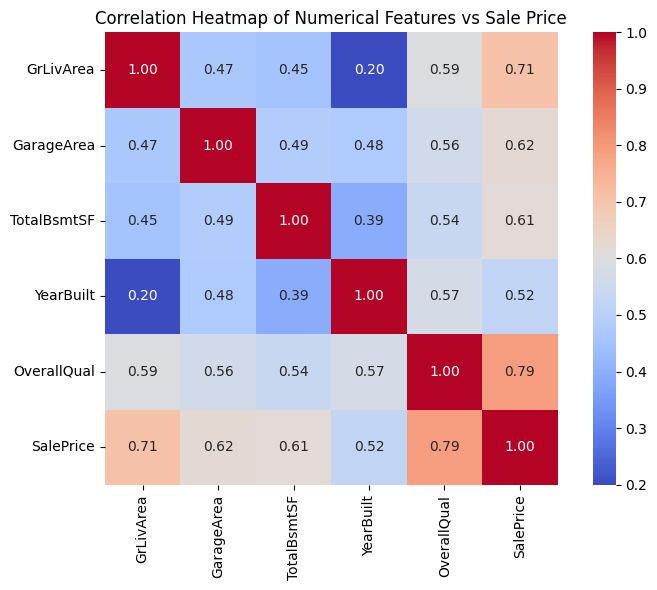

In [5]:
# Diagram 01: Feature Correlation Analysis - Heatmap

import seaborn as sns
import matplotlib.pyplot as plt



num_features = ['GrLivArea', 'GarageArea', 'TotalBsmtSF',
                'YearBuilt', 'OverallQual', 'SalePrice']

corr = train[num_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap of Numerical Features vs Sale Price')
plt.tight_layout()
plt.show()

# Heatmap guided the merging of area-related features;
# remaining feature engineering decisions were based on domain knowledge

In [6]:
# Cell 3: Feature Engineering

# ===== Create new features =====
# House age
all_data['HouseAge']     = all_data['YrSold'] - all_data['YearBuilt']
# Years since last remodel
all_data['RemodelAge']   = all_data['YrSold'] - all_data['YearRemodAdd']
# Total bathrooms
all_data['TotalBath']    = (all_data['FullBath'] + 0.5 * all_data['HalfBath'] +
                            all_data['BsmtFullBath'] + 0.5 * all_data['BsmtHalfBath'])
# Total area
all_data['TotalSF']      = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']
# Has garage
all_data['HasGarage']    = (all_data['GarageArea'] > 0).astype(int)
# Has basement
all_data['HasBsmt']      = (all_data['TotalBsmtSF'] > 0).astype(int)
# Has fireplace
all_data['HasFireplace'] = (all_data['Fireplaces'] > 0).astype(int)

print("New features created")
print(all_data[['HouseAge','TotalSF','TotalBath']].head())



New features created
   HouseAge  TotalSF  TotalBath
0         5   2566.0        3.5
1        31   2524.0        2.5
2         7   2706.0        3.5
3        91   2473.0        2.0
4         8   3343.0        3.5


In [7]:
# Label Encoding for categorical features
le = LabelEncoder()
for col in all_data.columns:
     # Check if column contains strings
    if all_data[col].apply(lambda x: isinstance(x, str)).any():
        all_data[col] = le.fit_transform(all_data[col].astype(str))

print("Encoding complete, data shape:", all_data.shape)

Encoding complete, data shape: (2919, 87)


In [ ]:
# Cell 5: Train Model

# Split back into train/test sets
n_train = train.shape[0]
X_train = all_data[:n_train].copy()
X_test  = all_data[n_train:].copy()
y_train = np.log1p(train['SalePrice'])   # log transform for more normal distribution   

# Fill any remaining NaN
X_train = X_train.fillna(0)
X_test  = X_test.fillna(0)

# --- Method 1: Random Forest ---
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
print(f"Random Forest CV RMSE: {-rf_scores.mean():.4f}")

# --- Method 2: Gradient Boosting ---
gb = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                max_depth=4, random_state=42)
gb_scores = cross_val_score(gb, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')

rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

print(f"Gradient Boosting CV RMSE: {-gb_scores.mean():.4f}")


# --- Method 3: Ridge (L2 Regularization) ---
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler

# Linear models need feature scaling first
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

ridge = Ridge(alpha=10)
ridge_scores = cross_val_score(ridge, X_train_scaled, y_train, cv=5,
                               scoring='neg_root_mean_squared_error')
print(f"Ridge CV RMSE: {-ridge_scores.mean():.4f}")

# --- Method 4: Lasso (L1 Regularization) ---
lasso = Lasso(alpha=0.001)
lasso_scores = cross_val_score(lasso, X_train_scaled, y_train, cv=5,
                               scoring='neg_root_mean_squared_error')
print(f"Lasso CV RMSE: {-lasso_scores.mean():.4f}")

# Fit both for later prediction use
ridge.fit(X_train_scaled, y_train)
lasso.fit(X_train_scaled, y_train)

Random Forest CV RMSE: 0.1415
Gradient Boosting CV RMSE: 0.1265
Ridge CV RMSE: 0.1495
Lasso CV RMSE: 0.1482


,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.001
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


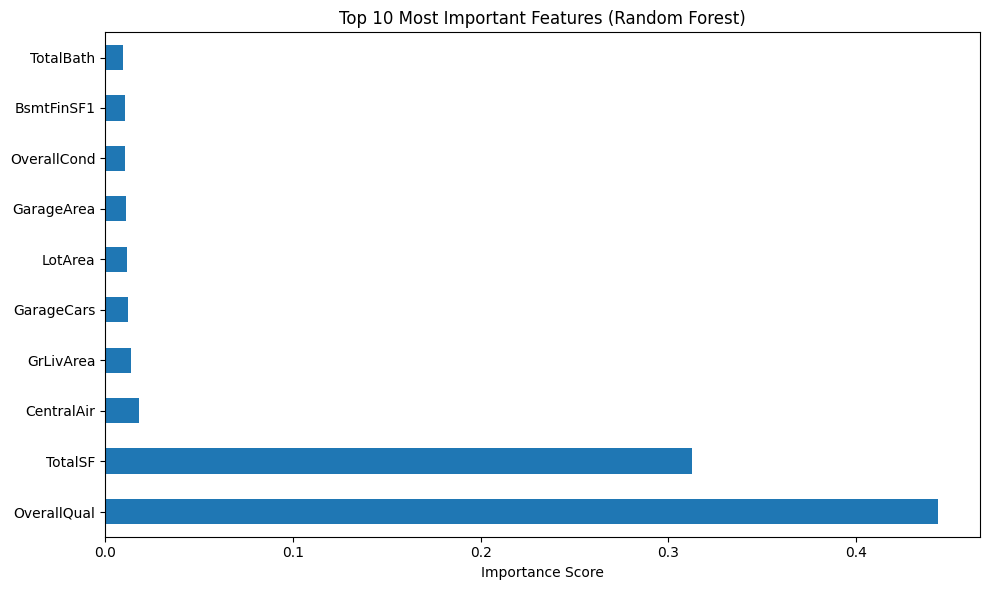

In [9]:
# Diagram 02: Feature Importance Analysis - Bar Chart

feature_importance = pd.Series(rf.feature_importances_, index=X_train.columns)
plt.figure(figsize=(10, 6))
feature_importance.nlargest(10).plot(kind='barh')
plt.title('Top 10 Most Important Features (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# OverallQual has the highest impact among original features,
# while TotalSF (engineered feature) ranks second,
# validating the decision to merge area-related features

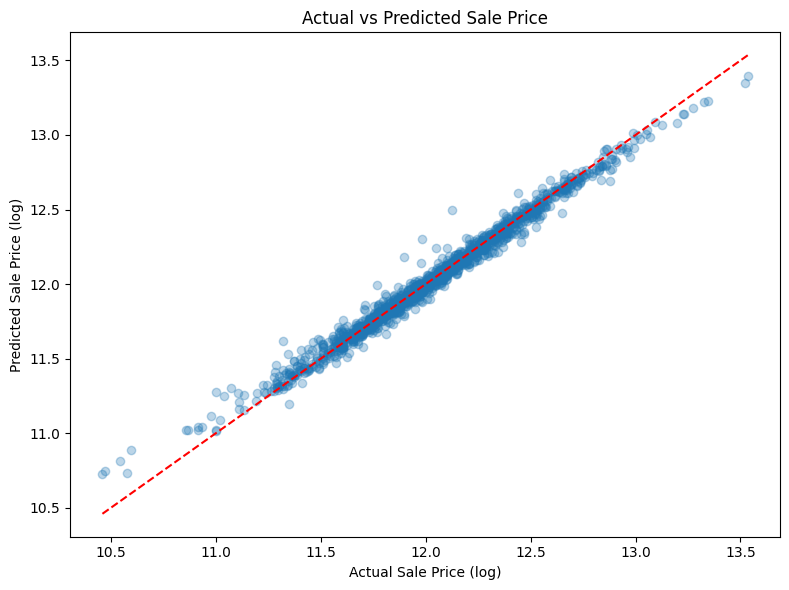

In [10]:
# Diagram 03: Prediction Result Analysis - Scatter Plot

y_pred_train = rf.predict(X_train)
plt.figure(figsize=(8, 6))
plt.scatter(y_train, y_pred_train, alpha=0.3)
plt.plot([y_train.min(), y_train.max()],
         [y_train.min(), y_train.max()], 'r--')
plt.xlabel('Actual Sale Price (log)')
plt.ylabel('Predicted Sale Price (log)')
plt.title('Actual vs Predicted Sale Price')
plt.tight_layout()
plt.show()

# Predicted values closely align with actual values.
# Model performs especially well on mid-range properties.
# Slight deviation at extreme price ranges, consistent with typical regression behaviour.



In [11]:
# Cell 6: Generate Submission

# Train both models and average predictions (ensemble)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)


# Average predictions from both models
pred_log = (rf.predict(X_test) + gb.predict(X_test)) / 2

# Average predictions from both models
pred_price = np.expm1(pred_log)

# Generate submission CSV
submission = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': pred_price
})
submission.to_csv('submission.csv', index=False)
print("Submission file generated!")
print(submission.head())

Submission file generated!
     Id      SalePrice
0  1461  123175.967945
1  1462  159720.135371
2  1463  176421.076976
3  1464  185518.552466
4  1465  186690.940401
